# **Course Task: Implementation of a Language Model (RNN and Transformer-based)**

This report details the implementation and evaluation of two small-scale
language models for causal language modeling (next-token prediction). The two
architectures implemented are:

* Gated Recurrent Unit (GRU) model, representing RNN architectures.

* GPT-style Transformer model, representing the transformer-based architecture.

Both models were implemented in PyTorch, trained on a Polish-language text
corpus, and evaluated on performance and efficiency metrics listed in the
problem statement.

## Dataset and Preprocessing

### Data Source

The training data consists of the collected works of Adam Mickiewicz. The data
was sourced from the Wolne Lektury digital library, which provides public domain
texts via an API.

### Data Acquisition and Cleaning

The `download.py` script was used to automatically fetch the data. It queries
the Wolne Lektury API endpoint:
https://wolnelektury.pl/api/authors/adam-mickiewicz/books/ and iterates through
the list of all available books by the author. For each book, it fetches the URL
for the plain text (.txt) version. All individual book texts are downloaded and
concatenated into a single file: `mickiewicz.txt`. A regular expression is
applied to clean the text by removing headers and footers that are part of the
Wolne Lektury formatting.

### Tokenization and Splitting

The models are **character-level**. The entire cleaned text is used to build a
vocabulary of all unique characters.

In [ ]:
# fmt:off
vocab = ['\n',' ','!',"'",'(',')','*',',','-','.','/','0','1','2','3','4',
         '5','6','7','8','9',':',';','?','A','B','C','D','E','F','G','H',
         'I','J','K','L','M','N','O','P','Q','R','S','T','U','V','W','X',
         'Y','Z','[',']','a','b','c','d','e','f','g','h','i','j','k','l',
         'm','n','o','p','q','r','s','t','u','v','w','x','y','z','«','»',
         'Ó','à','â','ä','æ','ç','è','é','ê','ó','ô','ü','Ą','ą','Ć','ć',
         'Ę','ę','Ł','ł','Ń','ń','Ś','ś','Ź','ź','Ż','ż','–','—','’','”',
         '„','…']
# fmt:on
vocab_size = len(vocab)
vocab_size

114

Each character is mapped to a unique integer index (stoi) and back (itos).

In [ ]:
itos = {i: ch for i, ch in enumerate(vocab)}
stoi = {ch: i for i, ch in enumerate(vocab)}

The full text corpus is converted into a single `torch.Tensor` of indices and
split into a 90% training set and a 10% validation set.

In [3]:
import torch

with open("data/mickiewicz.txt", encoding="utf-8") as file:
    text = file.read()

data = torch.tensor([stoi[ch] for ch in text], dtype=torch.long)
data_train = data[: int(0.9 * len(data))]
data_valid = data[int(0.9 * len(data)) :]

data_train[:64]

tensor([ 24,  55,  52,  64,   1,  36,  60,  54,  62,  60,  56,  74,  60,  54,
         77,   0,   0,  43,  66,   1,  63,  72,  53,  60,  97,   0,   0,   0,
          0,   1,   1,   1,   1,  42,  67,  66,  61,  69,  77,  76,  61,   7,
          1,  36,  52,  69,  76,  63,  66,   7,   1,  58,  55,  77,  60,  56,
          1,  70,  60,  97,   1,  62,  66, 101])

## Model Architectures

Both models were designed to have a comparable number of parameters (around 10M)
to facilitate a fair comparison, though the GRU implementation is inherently
more parameter-light for the same hidden dimension.

### GPT (Transformer) Model

The `GPTLanguageModel` is a decoder-only Transformer. It consists of:

1. Embeddings:
    - Token Embedding (`nn.Embedding`): Maps vocab_size to dim_model.
    - Positional Embedding (`nn.Embedding`): Learns a unique embedding for each
    position from 0 to block_size - 1. These are added to the token embeddings.

2. Transformer Blocks: A stack of 6 identical Block modules. Each Block consists
   of:
    - Pre-Normalization (`nn.LayerNorm`): Layer normalization is applied before
    the sub-layer (attention or FFN).

   - Multi-Head Self-Attention (`MultiHeadSelfAttention`): The input (dim_model)
    is linearly projected to 3 * dim_model and split into Query, Key, and Value
    matrices. These are reshaped to support `num_heads`.  The model uses
    `F.scaled_dot_product_attention` (Flash Attention) if available, with
    `is_causal=True` to ensure tokens only attend to previous tokens. A fallback
    path with a manually implemented attention operation is included. A final
    linear projection and dropout are applied.

    - Feed-Forward Network (`FeedForward`): A standard 2-layer MLP with a GELU
      activation. It expands the dimension dim_model -> 4 * dim_model ->
      dim_model.

    - Residual Connections: The output of each sub-layer (attention and FFN) is
    added back to its input.

3. Output Head: A final `nn.LayerNorm` is applied, followed by a `nn.Linear`
   layer to map the output to `vocab_size` logits.

With these hyperparameters, the GPT model has approximately
10.8M parameters.

In [44]:
from gpt import GPTLanguageModel

block_size = 256
num_layers = 6
num_heads = 6
dim_model = 384
dropout_p = 0.2

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    num_layers=num_layers,
    dim_model=dim_model,
    num_heads=num_heads,
    dropout_p=dropout_p,
)
print(f"{sum(p.numel() for p in model.parameters()) / 1e6}M parameters")

10.824306M parameters


### GRU Model

The `GRULanguageModel` is a standard RNN-based sequence model. It consists of

1. Token Embedding (`nn.Embedding`): Maps the input character indices (`vocab_size`)
   to the model's hidden dimension (`dim_model`).

2. GRU Layer (nn.GRU): The core of the model. It takes the `dim_model`
   embeddings as input and has a hidden state of the same size. It is configured
   with `num_layers` stacked on top of each other. Dropout of 0.2 is applied
   between GRU layers. `batch_first=True` is set to match the data shape `(B, T,
   C)`.

3. Output Head (`nn.Linear`): A final linear layer maps the GRU's output hidden
   states (`dim_model`) back to the vocabulary size (`vocab_size`) to produce
   logits for the next token prediction.

With these hyperparameters, the GRU model has approximately 9.6M parameters.

In [43]:
from gru import GRULanguageModel

block_size = 256
num_layers = 6
dim_model = 512
dropout_p = 0.2

model = GRULanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    num_layers=num_layers,
    dim_model=dim_model,
    dropout_p=dropout_p,
)
print(f"{sum(p.numel() for p in model.parameters()) / 1e6}M parameters")

9.572466M parameters


## Training

Both models were trained for 5000 epochs on a NVIDIA GTX 1660 Super GPU with 6GB
of VRAM. The batch size used was 64 and the models where evaluated every 500
epochs on a validation set. The training setup was as following.

In [8]:
batch_size = 64
log_period = 500
num_epochs = 5000
num_evals = 200

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

### Training time

* GPT Model Training Time: ~39 min
* GRU Model Training Time: ~37 min

### Training and Validation Loss

The training losses were logged at each epoch while validation loss was
estimated every 500 epochs. The following Python script can be used to load a
checkpoint file and plot the complete loss history using matplotlib.

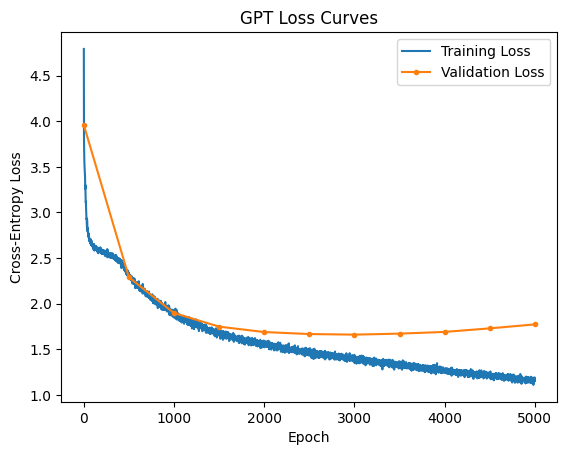

In [ ]:
import matplotlib.pyplot as plt

loss_hist = torch.load("checkpoints/gpt/chk_4999.pt")["loss"]

train_loss_epochs = sorted(loss_hist["train"].keys())
train_loss_values = [loss_hist["train"][e] for e in train_loss_epochs]

valid_loss_epochs = sorted(loss_hist["valid"].keys())
valid_loss_values = [loss_hist["valid"][e] for e in valid_loss_epochs]

plt.plot(train_loss_epochs, train_loss_values, label="Training Loss")
plt.plot(valid_loss_epochs, valid_loss_values, label="Validation Loss", marker=".")
plt.title("GPT Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()

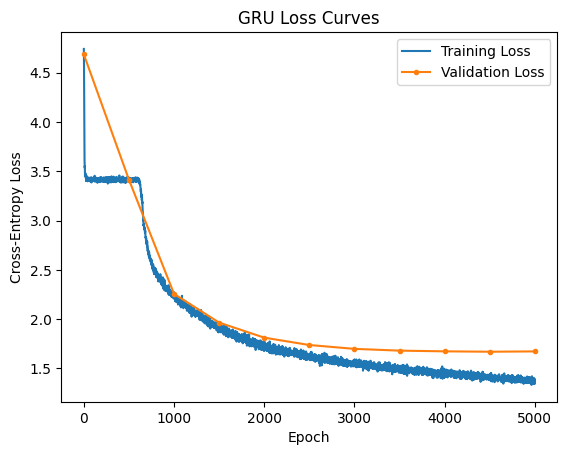

In [ ]:
loss_hist = torch.load("checkpoints/gru/chk_4999.pt")["loss"]

train_loss_epochs = sorted(loss_hist["train"].keys())
train_loss_values = [loss_hist["train"][e] for e in train_loss_epochs]

valid_loss_epochs = sorted(loss_hist["valid"].keys())
valid_loss_values = [loss_hist["valid"][e] for e in valid_loss_epochs]

plt.plot(train_loss_epochs, train_loss_values, label="Training Loss")
plt.plot(valid_loss_epochs, valid_loss_values, label="Validation Loss", marker=".")
plt.title("GRU Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()

## Evaluation Results

In [32]:
type DeviceLikeType = str | torch.device

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device.upper()}")

Using device: CUDA


In [ ]:
from gpt import GPTLanguageModel

gpt = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=256,
    num_layers=6,
    dim_model=384,
    num_heads=6,
    dropout_p=0.2,
).to(device)

gpt_chkpt = torch.load("checkpoints/gpt/chk_4999.pt")
gpt.load_state_dict(gpt_chkpt["model"])
gpt.eval()

In [ ]:
from gru import GRULanguageModel

gru = GRULanguageModel(
    vocab_size=vocab_size,
    block_size=256,
    num_layers=6,
    dim_model=512,
    dropout_p=0.2,
).to(device)

gru_chkpt = torch.load("checkpoints/gru/chk_4999.pt")
gru.load_state_dict(gru_chkpt["model"])
gru.eval()

### Perplexity

Perplexity (PPL) is the standard metric for language model evaluation,
calculated as the exponent of the cross-entropy loss: $PPL = \exp(\text{Loss})$.

In [56]:
from math import exp

loss_hist = torch.load("checkpoints/gpt/chk_4999.pt")["loss"]
print(f"GPT Perplexity: {exp(loss_hist["valid"][4999]):.4f}")

GPT Perplexity: 5.8852


In [57]:
loss_hist = torch.load("checkpoints/gru/chk_4999.pt")["loss"]
print(f"GRU Perplexity: {exp(loss_hist["valid"][4999]):.4f}")

GRU Perplexity: 5.3219


### Inference throughput

Inference Throughput is measured in tokens per second.

In [28]:
import time


@torch.no_grad()
def measure_inference_throughput(model, num_toks_to_gen: int, device: DeviceLikeType):
    """Measures inference speed in tokens per second."""
    model.eval()
    ctx = torch.tensor([0], dtype=torch.long).to(device)

    t = time.perf_counter()
    for _ in model.generate(ctx, out_size=num_toks_to_gen):
        pass
    t = time.perf_counter() - t

    toks_per_sec = num_toks_to_gen / t
    print(f"Generated {num_toks_to_gen} tokens in {t:.4f} seconds.")
    print(f"Inference Throughput: ~{toks_per_sec:.2f} tokens/second")

In [29]:
measure_inference_throughput(gpt, num_toks_to_gen=1000, device=device)

Generated 1000 tokens in 3.2943 seconds.
Inference Throughput: ~303.55 tokens/second


In [30]:
measure_inference_throughput(gru, num_toks_to_gen=1000, device=device)

Generated 1000 tokens in 20.4297 seconds.
Inference Throughput: ~48.95 tokens/second


## Prompt completions

In [47]:
ctx = torch.tensor([0], dtype=torch.long).to(device)
print("".join(itos[tok] for tok in gpt.generate(ctx, 512)))

Przyniósł mu się pomiędzy nim tym był celu?
Ach, w śniegu zapaliłeś, nieprzyjacielu,
Niechaj utrąbę znalazłeś kochanek
Mnie, jak zwykłeś róże liliji i winy
Z cierpienia na swego cierpieniach, i nawet bez grzechu.
Niech ćmi wkoło polskich wzmogłych, w ziemi czeka!
Nędznych pocałun wyciągnął przed światem:
Róg posłyszał, niech i śpiewają oko,
Przebóg! czemu zawołając światełka.

  Poszli na nic rada.
Potem cud, kończy stojący z lekka:
Tym się lękając śród jęku
Stała w środku jako ściele świeci,
Tym falampa mo


In [54]:
ctx = torch.tensor([0], dtype=torch.long).to(device)
print("".join(itos[tok] for tok in gpt.generate(ctx, 512)))

Kiedy mu uciszczał, z dala grzbiety złych wyprawiał,
I kozach myśli, że się podaszał.
Lecz natenczas najpierwszy papiery ułan Sędzia:
Wiedział, że sam uczuł, że ten z cicha łajatwa
Z biorącego zwiedzianego szukać na wschód spojrzał ręka;
Tak, Hrabia poznał się Telimena — Znak, że są chwyta
Wysuwał się, zdawało: już nie mogąc słońcem powzórcone słonem,
Chciał zbrojnym; w boku ruszono ku Zosię, potchmała
Ściele równie, czułem w zapomnieniu, czułam zaraz bytch schodziła,
Jak gdyby człowiek myślisz, jak już nie


## Discussion and Challenges 

### Resource constraints

The primary challenge was the limitation of available GPU VRAM. Training
large-scale language models is computationally expensive. The models were
intentionally kept small (~10M parameters) to be trainable on consumer-grade
hardware in reasonable amount of time. This size, while feasible for the
assignment, is orders of magnitude smaller than state-of-the-art models.

### Character-Level Tokenization

The choice of character-level tokenization was for simplicity. However, it
presents a major bottleneck. The `block_size` of 256 characters represents a
very small window of text (perhaps 40-50 words).